# 21 · Pain medication escalation as a patient-centered outcome

Instead of the 0–4 NP1PAIN item, use the Concomitant Medication Log to define an **analgesic escalation** outcome: did the patient start or step up their analgesic regimen in the post-anchor window? Compare DBS vs Never-DBS.

Escalation ladder (low → high):
1. None
2. Acetaminophen only
3. NSAID (with/without acetaminophen)
4. Neuropathic (gabapentinoid / duloxetine / amitriptyline)
5. Opioid (including tramadol)

Each patient gets a pre-anchor level and a post-anchor level. **Escalation** = post > pre. **De-escalation** = post < pre.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({ library(dplyr); library(tidyr); library(ggplot2); library(lubridate); library(stringr); library(purrr) })
path_conmed <- file.path(PROJECT_ROOT, "Propensity score DBS sleep", "Data I need to merge", "Concomitant_Medication_Log_04Nov2024.csv")
cm <- readr::read_csv(path_conmed, show_col_types = FALSE) %>%
  dplyr::mutate(PATNO = as.integer(PATNO), CMTRT = toupper(CMTRT),
                STARTDT = suppressWarnings(lubridate::my(STARTDT)),
                STOPDT  = suppressWarnings(lubridate::my(STOPDT)))

# Classify drug by level (highest wins)
level_of <- function(names) {
  rx_opi <- toupper(paste(ANALGESIC_CLASSES$opioid, collapse = "|"))
  rx_neu <- toupper(paste(ANALGESIC_CLASSES$neuropathic, collapse = "|"))
  rx_nsa <- toupper(paste(ANALGESIC_CLASSES$nsaid, collapse = "|"))
  rx_ace <- toupper(paste(ANALGESIC_CLASSES$acetaminophen, collapse = "|"))
  lvl <- rep(0L, length(names))
  lvl[stringr::str_detect(names, rx_ace)] <- 1L
  lvl[stringr::str_detect(names, rx_nsa)] <- 2L
  lvl[stringr::str_detect(names, rx_neu)] <- 3L
  lvl[stringr::str_detect(names, rx_opi)] <- 4L
  lvl
}
cm$level <- level_of(dplyr::coalesce(cm$CMTRT, ""))
cat("Level distribution (drug rows):\n"); print(table(cm$level))

Level distribution (drug rows):



    0     1     2     3     4 
39974   383  1108   813   278 


In [2]:
# Patient-anchor dates
rel <- load_full_ppmi_rel_patient_anchor()
anchors <- rel %>% dplyr::distinct(PATNO, will_receive_dbs, anchor_date)

# Per-patient maximum level in each window
window_level <- function(cm_in, anchors_in, lo, hi) {
  cm_in %>% dplyr::inner_join(anchors_in, by = "PATNO") %>%
    dplyr::mutate(
      start_rel = as.numeric(difftime(STARTDT, anchor_date, units = "days")) / DAYS_PER_MONTH,
      stop_rel  = as.numeric(difftime(dplyr::coalesce(STOPDT, as.Date("2099-12-31")), anchor_date, units = "days")) / DAYS_PER_MONTH
    ) %>%
    dplyr::filter(!is.na(start_rel), start_rel <= hi, stop_rel >= lo) %>%
    dplyr::group_by(PATNO) %>% dplyr::summarise(max_level = max(level, na.rm = TRUE), .groups = "drop")
}
pre  <- window_level(cm, anchors, -12, 0) %>% dplyr::rename(pre_level  = max_level)
post <- window_level(cm, anchors,   6, 18) %>% dplyr::rename(post_level = max_level)

per_pat <- anchors %>% dplyr::left_join(pre, by = "PATNO") %>% dplyr::left_join(post, by = "PATNO") %>%
  dplyr::mutate(pre_level = dplyr::coalesce(pre_level, 0L), post_level = dplyr::coalesce(post_level, 0L),
                change = post_level - pre_level,
                status = dplyr::case_when(
                  change > 0 ~ "Escalated",
                  change < 0 ~ "De-escalated",
                  pre_level > 0 ~ "Stable (on analgesic)",
                  TRUE ~ "Stable (no analgesic)"
                ))
print(per_pat %>% dplyr::count(will_receive_dbs, status) %>% tidyr::pivot_wider(names_from = status, values_from = n, values_fill = 0))
save_object(per_pat, "analgesic_level_per_patient")

# A tibble: 2 × 4
  will_receive_dbs Escalated `Stable (no analgesic)` `Stable (on analgesic)`
  <lgl>                <int>                   <int>                   <int>
1 FALSE                   12                    1312                      55
2 TRUE                     2                      94                       9


In [3]:
# Fisher test: escalation by arm
esc <- per_pat %>% dplyr::mutate(escalated = change > 0)
tab <- table(esc$will_receive_dbs, esc$escalated)
print(tab)
f_esc <- stats::fisher.test(tab)
print(f_esc)

# Among patients with non-zero pre_level, proportion de-escalated
on_pre <- per_pat %>% dplyr::filter(pre_level > 0)
cat("Patients on analgesic pre:", nrow(on_pre), "\n")
tab_d <- table(on_pre$will_receive_dbs, on_pre$change < 0)
print(tab_d)
if (all(dim(tab_d) == c(2,2))) {
  print(stats::fisher.test(tab_d))
}

       
        FALSE TRUE
  FALSE  1367   12
  TRUE    103    2



	Fisher's Exact Test for Count Data

data:  tab
p-value = 0.2603
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
  0.2371881 10.1311633
sample estimates:
odds ratio 
  2.210316 



Patients on analgesic pre: 64 


       
        FALSE
  FALSE    55
  TRUE      9


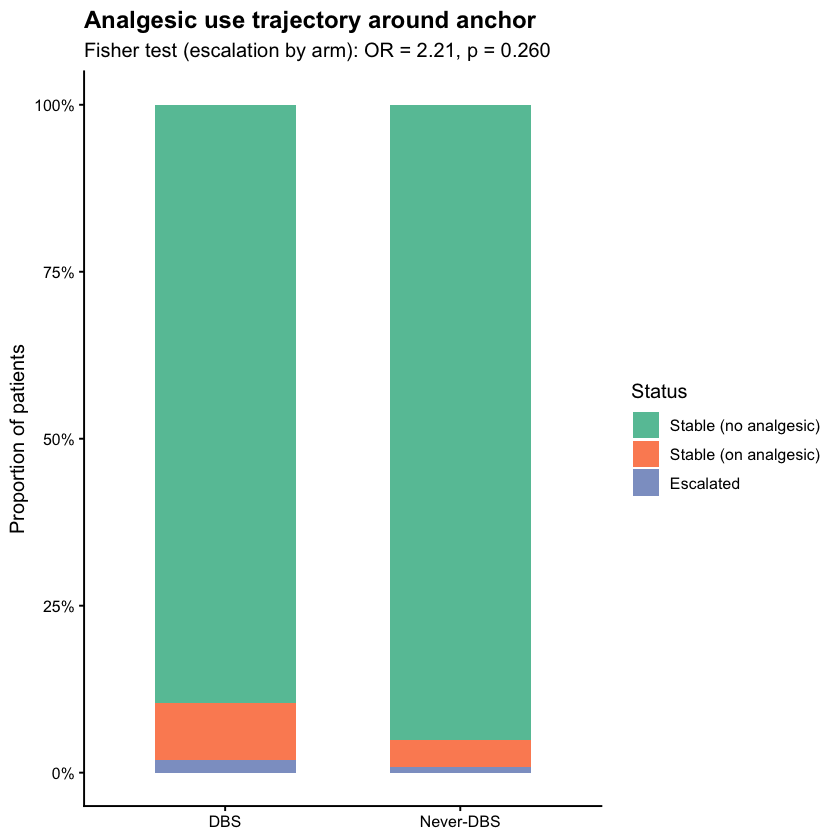

In [4]:
arm_labs <- c(`TRUE` = "DBS", `FALSE` = "Never-DBS")
p_stat <- per_pat %>% dplyr::count(will_receive_dbs, status) %>%
  dplyr::group_by(will_receive_dbs) %>% dplyr::mutate(prop = n / sum(n)) %>% dplyr::ungroup() %>%
  dplyr::mutate(arm = dplyr::recode(as.character(will_receive_dbs), !!!arm_labs),
                status = factor(status, levels = c("Stable (no analgesic)","De-escalated","Stable (on analgesic)","Escalated")))
p_bar <- ggplot(p_stat, aes(x = arm, y = prop, fill = status)) +
  geom_col(position = "fill", width = 0.6) +
  scale_y_continuous("Proportion of patients", labels = scales::percent_format()) +
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Analgesic use trajectory around anchor",
       subtitle = sprintf("Fisher test (escalation by arm): OR = %.2f, p = %.3f",
                          f_esc$estimate, f_esc$p.value),
       x = NULL, fill = "Status") +
  theme_classic(base_size = 12) + theme(plot.title = element_text(face = "bold"))
p_bar
save_fig(p_bar, "Figure16_analgesic_escalation", width = 7.5, height = 4.4)

In [5]:
# Does analgesic escalation correlate with NP1PAIN worsening? (convergent validity)
dat <- readRDS(file.path(OUT_OBJ, "patient_anchor_features.rds")) %>%
  dplyr::left_join(per_pat %>% dplyr::select(PATNO, pre_level, post_level, change, status), by = "PATNO")
tab_conv <- table(dat$worsened, dat$status, useNA = "ifany")
print(tab_conv)
save_table(as.data.frame.matrix(tab_conv) %>% tibble::rownames_to_column("worsened"),
           "worsened_vs_med_status")

   
    Escalated Stable (no analgesic) Stable (on analgesic)
  0         6                   510                    25
  1         2                    92                     7
